In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.least_squares import LinearRegression, PowerLawRegression
from src.SGD import SGD, NoisyGD
from scheduled import WSDSchedule, ConstantSchedule
from src.new_schedules.polynomial import PolynomialSchedule
import src.utils as utils
from src.visualization import Visualization

from src.risk_computations import RiskComputations


In [10]:
T=1000
sigma = 0.1
dim = 50

eta = 0.1
eta_range = np.logspace(-4, 0, 50)
t_values = np.linspace(0, T-1, 10, dtype=int)

model = PowerLawRegression(dim=dim, sigma=sigma, exponent=2)

wsd = WSDSchedule(steps=T, base_lr=eta, cooldown_len=0.2)
constant = ConstantSchedule(steps=T, base_lr=eta)
linear = WSDSchedule(steps=T, base_lr=eta, cooldown_len=1.)

x0 = np.random.multivariate_normal(np.zeros(dim), np.eye(dim))

risks = RiskComputations(model, x0, schedules=[wsd, constant, linear], schedules_names=["wsd", "constant", "linear"], sgd_class=SGD)


In [11]:
risks.optimize_all_base_lrs(eta_range=np.logspace(-4, 0.5, 50), change_eta=True, save_results=True)

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_16-17-55.json


{'wsd': {'best_eta': 0.47148663634573945, 'min_risk': 0.016572232937828665},
 'constant': {'best_eta': 0.3088843596477482, 'min_risk': 0.03142975654504972},
 'linear': {'best_eta': 0.5825136712468927, 'min_risk': 0.02299993155976663}}

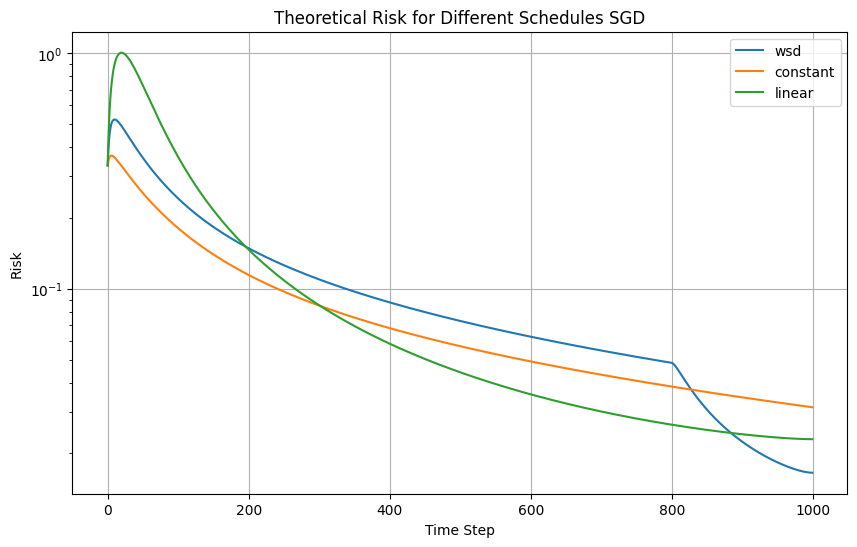

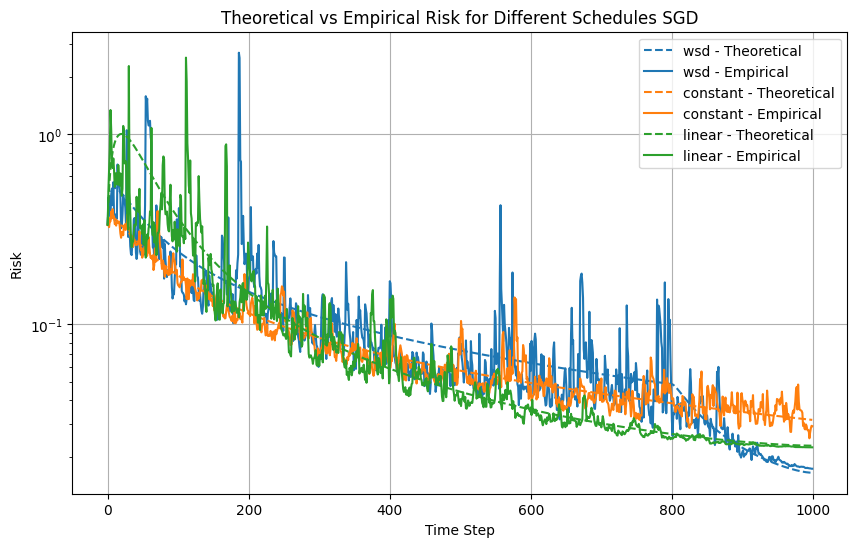

In [12]:
theoretical_risks = risks.compute_all_theoretical_risks()
all_risks = risks.compute_all_risks(n_runs=10)

visualization = Visualization([wsd, constant, linear], ["wsd", "constant", "linear"])
visualization.plot_for_every_schedule(
    theoretical_risks,
    title="Theoretical Risk for Different Schedules SGD",
    logscale=True,
    savefig=True,
    filename="Theoretical_Risk_Schedules_SGD"
    )
visualization.plot_comparison(
    all_risks["theoretical"],
    all_risks["empirical"],
    title="Theoretical vs Empirical Risk for Different Schedules SGD",
    logscale=True,
    )


In [13]:
optimization = risks.optimize_at_several_ts(t_values=np.linspace(0, 999, 20, dtype=int), eta_range=np.logspace(-4, 1, 50), change_eta=True, save_results=True)

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_several_ts_2026-04-16_16-18-08.json


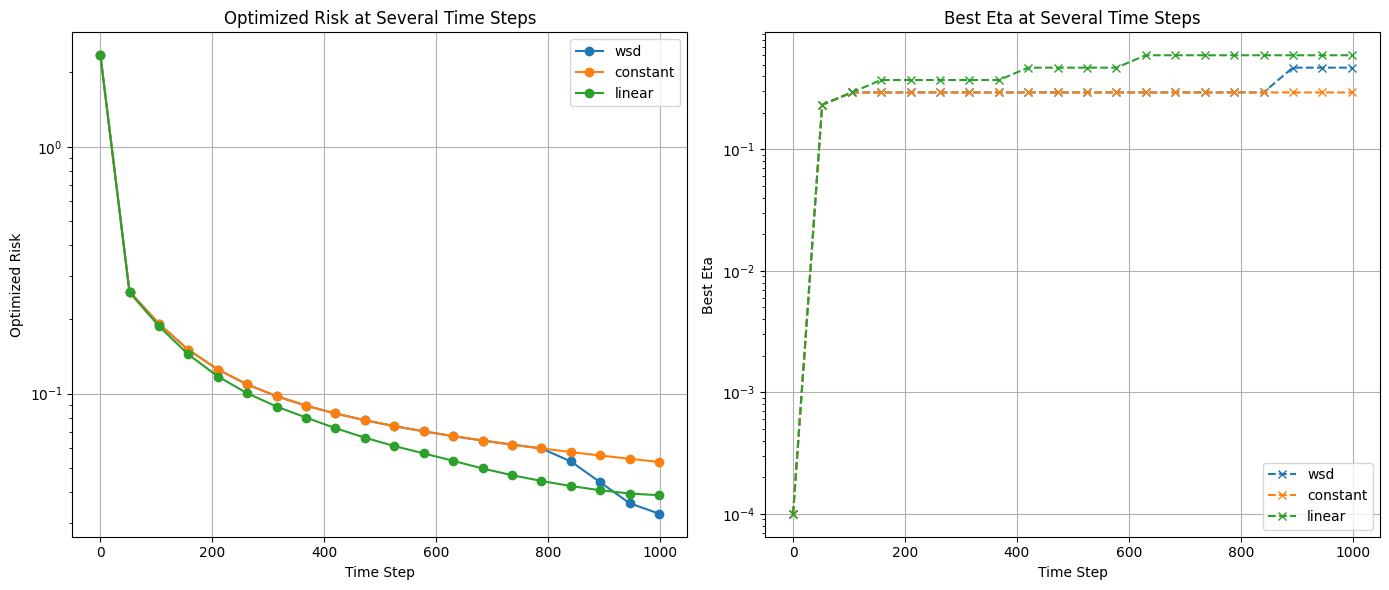

In [16]:
visualization.plot_optimization_at_several_ts(
    optimization, legend=True, plot_etas=True, savefig=False, logscale=True, filename=None)

Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_16-18-17.json


c:\Users\ordinateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: overflow encountered in multiply
  m_t = P_t_vector * m_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:172: RuntimeWarning: overflow encountered in multiply
  v_t = P_t_vector * v_t + noise_t


Optimization results saved to saved_files\base_lr\optimize_results_Noisy GD_t_value_final_2026-04-16_16-18-24.json


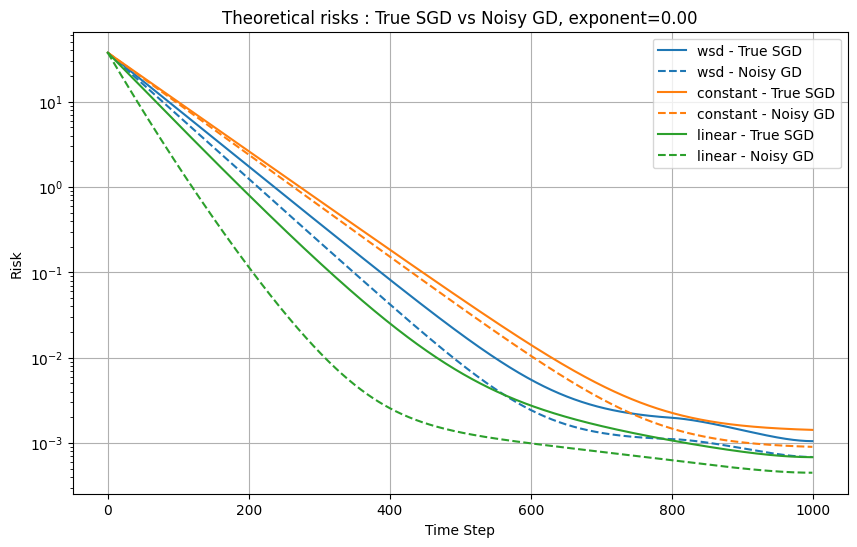

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_16-18-33.json


c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: overflow encountered in multiply
  m_t = P_t_vector * m_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:172: RuntimeWarning: overflow encountered in multiply
  v_t = P_t_vector * v_t + noise_t


Optimization results saved to saved_files\base_lr\optimize_results_Noisy GD_t_value_final_2026-04-16_16-18-40.json


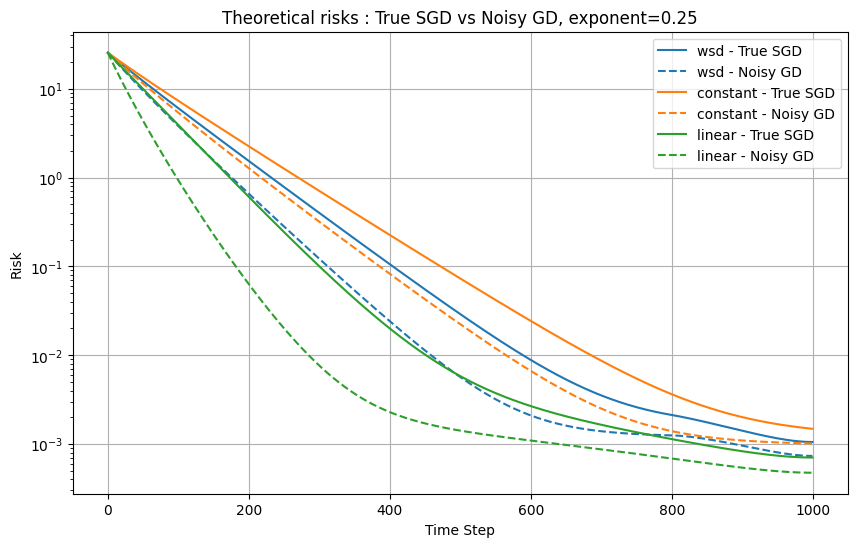

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_16-18-49.json


c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:172: RuntimeWarning: overflow encountered in multiply
  v_t = P_t_vector * v_t + noise_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: overflow encountered in multiply
  m_t = P_t_vector * m_t


Optimization results saved to saved_files\base_lr\optimize_results_Noisy GD_t_value_final_2026-04-16_16-18-56.json


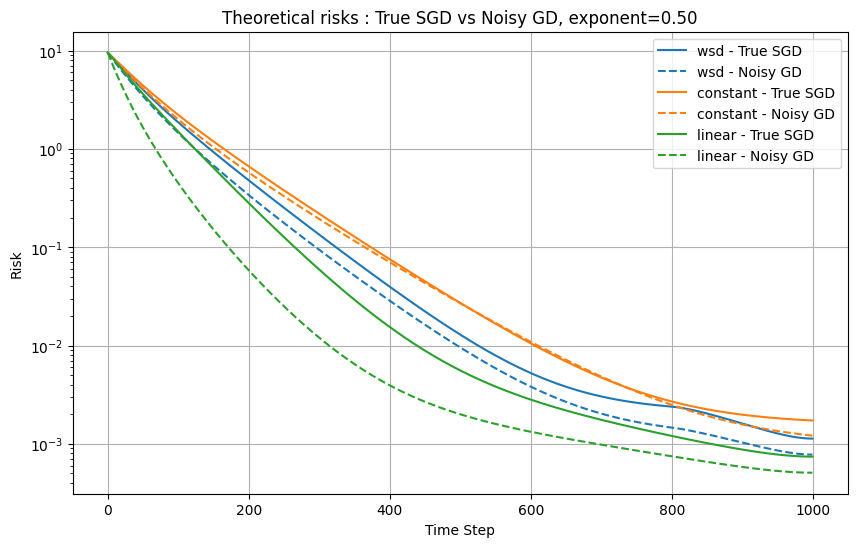

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_16-19-07.json


c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: overflow encountered in multiply
  m_t = P_t_vector * m_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:172: RuntimeWarning: overflow encountered in multiply
  v_t = P_t_vector * v_t + noise_t


Optimization results saved to saved_files\base_lr\optimize_results_Noisy GD_t_value_final_2026-04-16_16-19-15.json


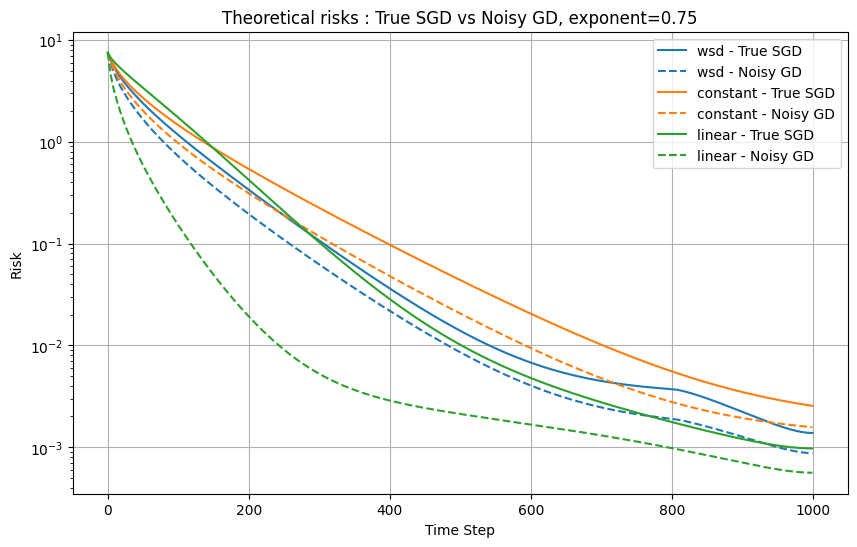

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_16-19-23.json


c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: overflow encountered in multiply
  m_t = P_t_vector * m_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:172: RuntimeWarning: overflow encountered in multiply
  v_t = P_t_vector * v_t + noise_t


Optimization results saved to saved_files\base_lr\optimize_results_Noisy GD_t_value_final_2026-04-16_16-19-30.json


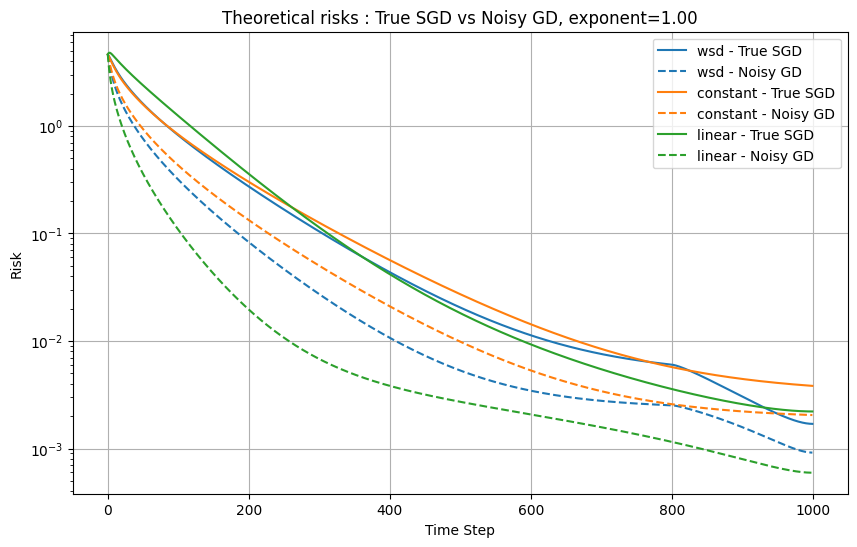

In [14]:
import copy

schedules_names = ["wsd", "constant", "linear"]
schedules = [wsd, constant, linear]
schedules_noisy = [copy.deepcopy(schedule) for schedule in schedules]
visu = Visualization(schedules, schedules_names)


def compute_different_exponents_theoretical_vs_noisy(exponent_range=np.linspace(1,2,10)):

    for exponent in exponent_range:
        model = PowerLawRegression(dim=dim, sigma=sigma, exponent=exponent)

        risk_computation_sgd = RiskComputations(model, x0, schedules, schedules_names, sgd_class=SGD)
        risk_computation_noisy = RiskComputations(model, x0, schedules_noisy, schedules_names, sgd_class=NoisyGD)

        risk_computation_sgd.optimize_all_base_lrs(eta_range=np.logspace(-4, 0.5, 50), change_eta=True, save_results=True)
        risk_computation_noisy.optimize_all_base_lrs(eta_range=np.logspace(-4, 0.5, 50), change_eta=True, save_results=True)

        risks_sgd_data = risk_computation_sgd.compute_all_theoretical_risks()
        risks_noisy_data = risk_computation_noisy.compute_all_theoretical_risks()  

        visu.plot_sgd_classes_comparison(
            risks_class1=risks_sgd_data, 
            risks_class2=risks_noisy_data, 
            label_class1=SGD.name,       # Récupère "True SGD"
            label_class2=NoisyGD.name,   # Récupère "Noisy GD"
            title="Theoretical risks : True SGD vs Noisy GD, exponent={:.2f}".format(exponent),
            logscale=True,
            savefig=True
        )

compute_different_exponents_theoretical_vs_noisy(np.linspace(0,1,5))

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_16-19-40.json


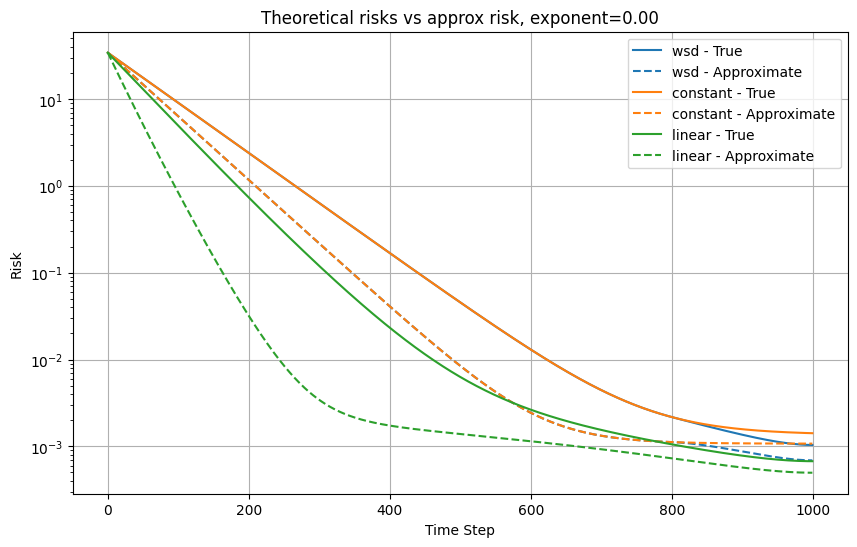

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_16-19-49.json


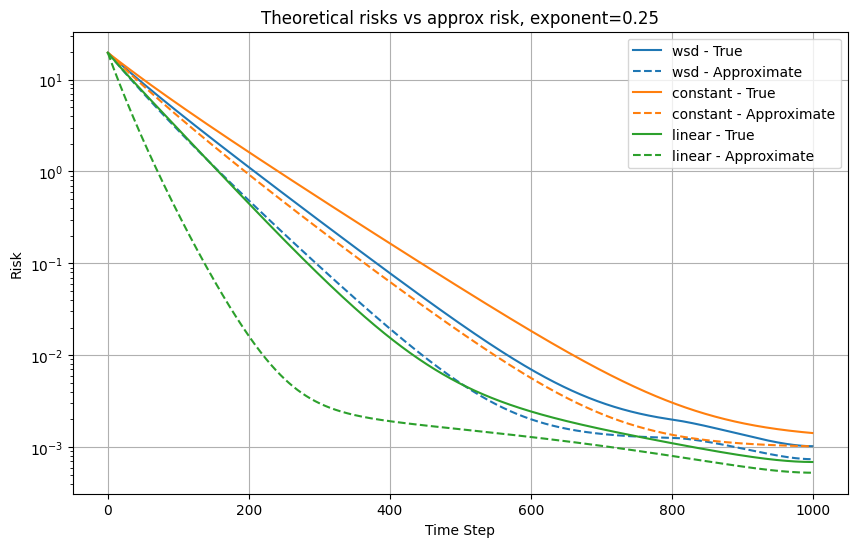

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_16-19-57.json


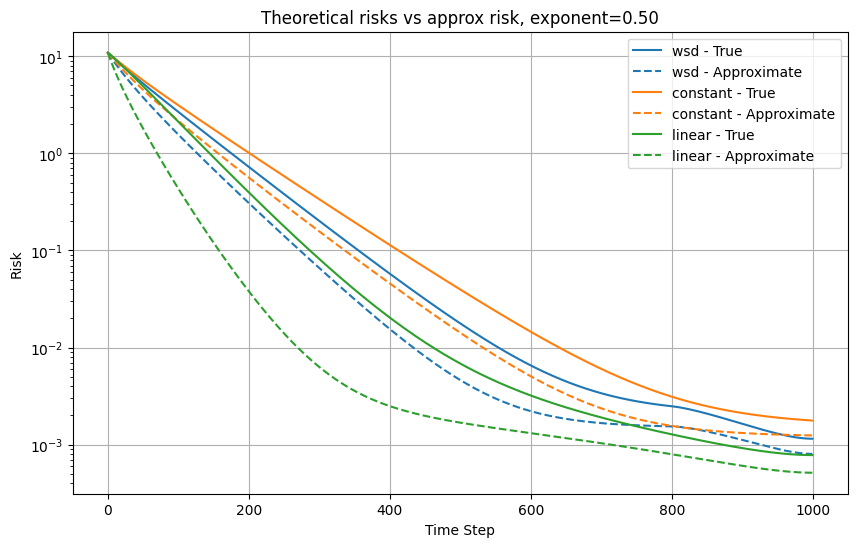

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_16-20-06.json


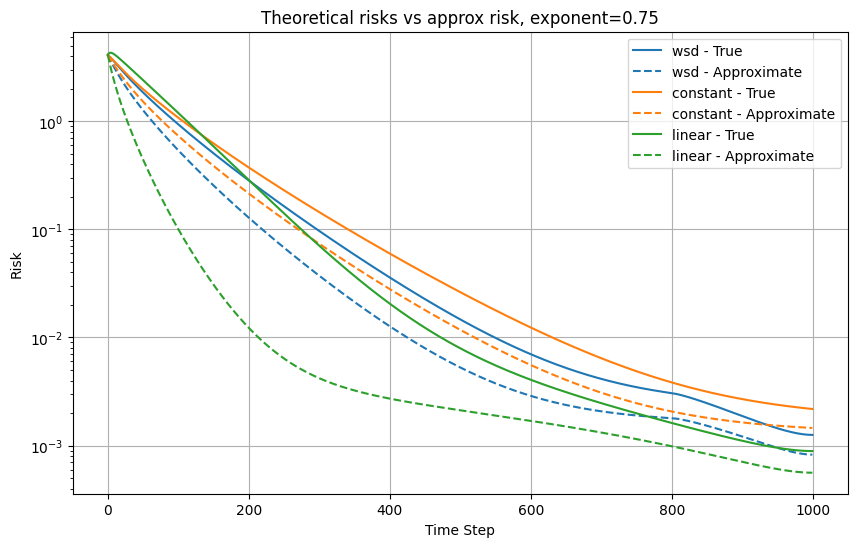

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_16-20-16.json


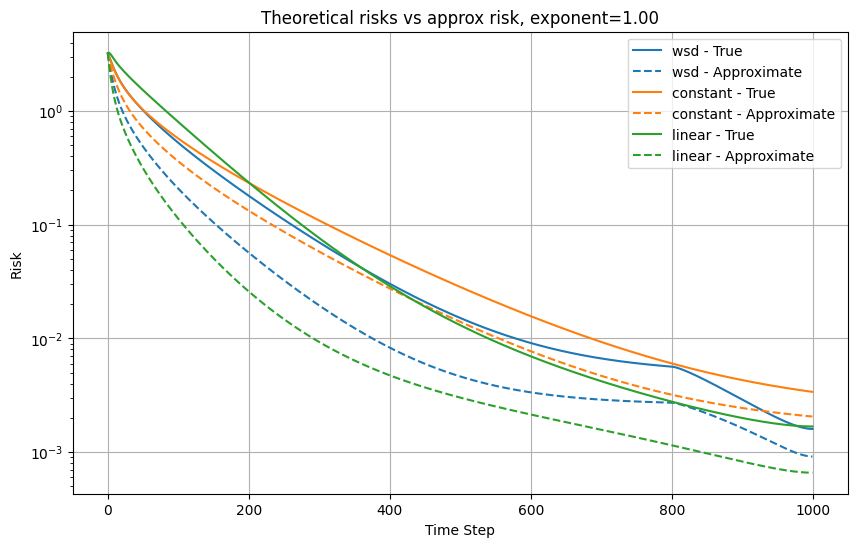

In [15]:
for exponent in np.linspace(0, 1, 5):
    model = PowerLawRegression(dim=dim, sigma=sigma, exponent=exponent)

    risk_computation_sgd = RiskComputations(model, x0, schedules, schedules_names, sgd_class=SGD)

    risk_computation_sgd.optimize_all_base_lrs(eta_range=np.logspace(-4, 0.5, 50), change_eta=True, save_results=True)

    risks_sgd_data = risk_computation_sgd.compute_approx_vs_theoretical_risks()

    visu.plot_sgd_classes_comparison(
        risks_sgd_data["theoretical"],
        risks_sgd_data["approximate"],
        label_class1="True",
        label_class2="Approximate",
        title="Theoretical risks vs approx risk, exponent={:.2f}".format(exponent),
        logscale=True,
        savefig=True
    )

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_16-20-41.json


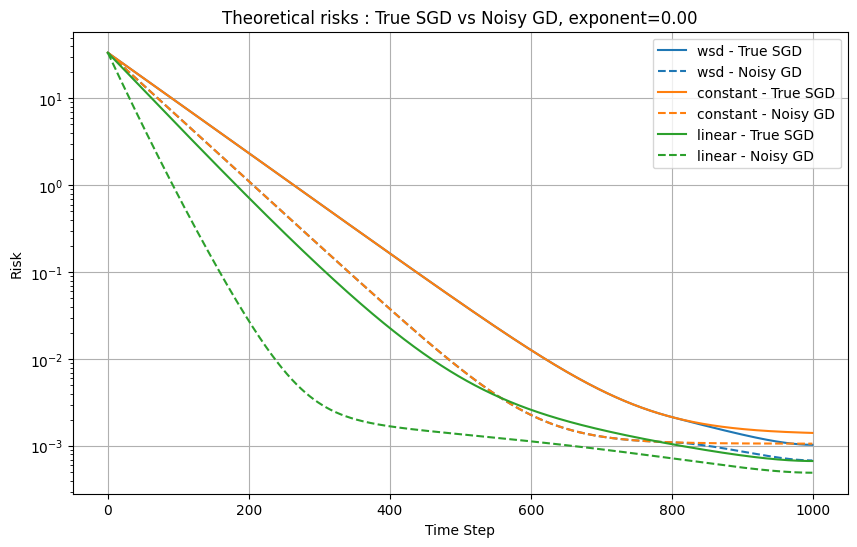

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_16-20-49.json


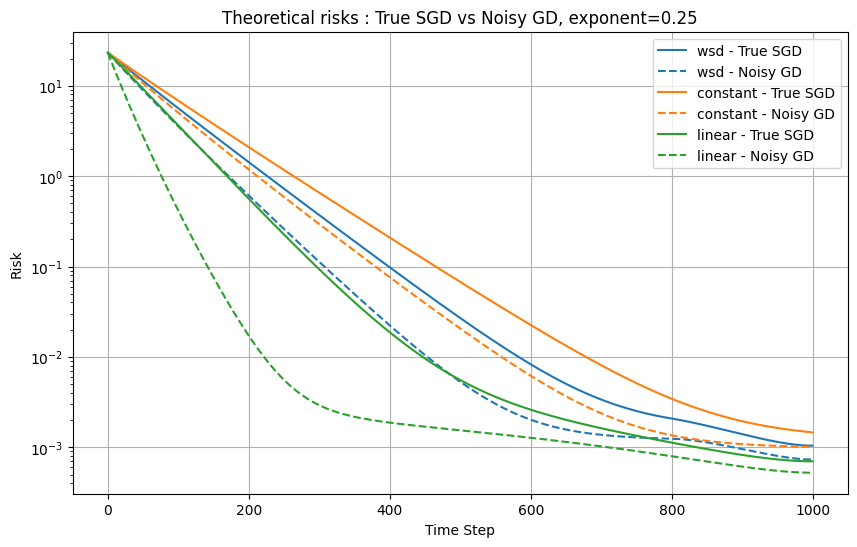

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_16-20-57.json


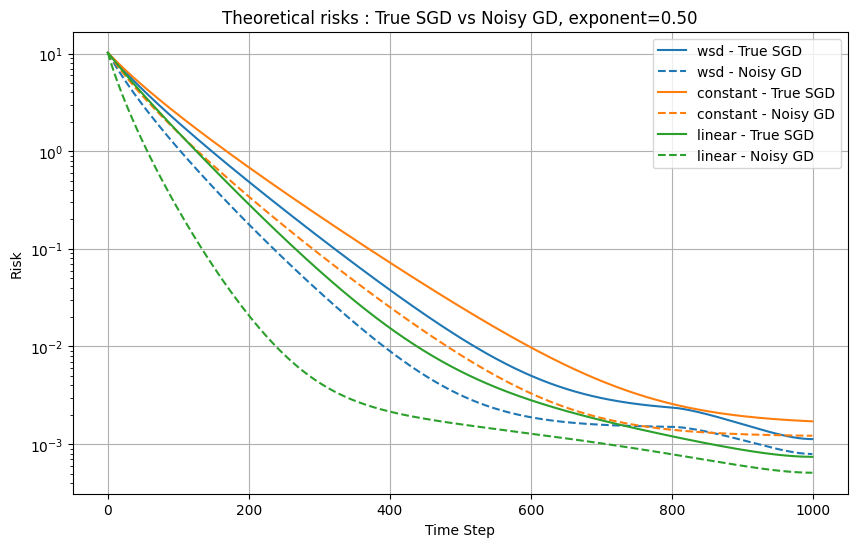

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_16-21-06.json


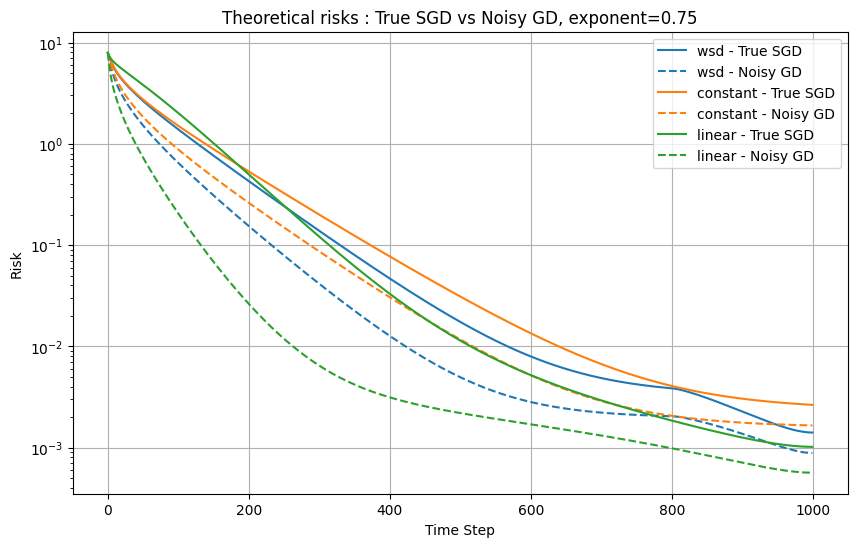

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-16_16-21-15.json


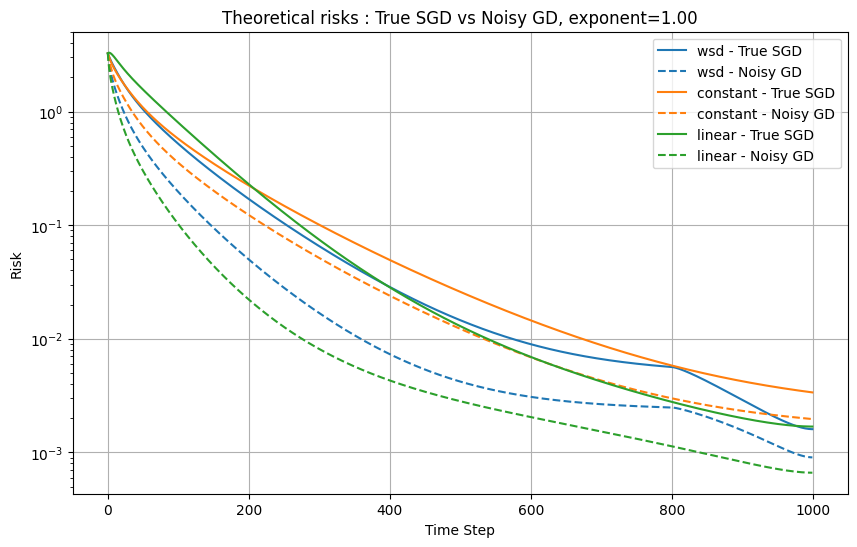

In [16]:
for exponent in np.linspace(0,1,5):
        model = PowerLawRegression(dim=dim, sigma=sigma, exponent=exponent)

        risk_computation_sgd = RiskComputations(model, x0, schedules, schedules_names, sgd_class=SGD)
        risk_computation_noisy = RiskComputations(model, x0, schedules, schedules_names, sgd_class=NoisyGD)

        risk_computation_sgd.optimize_all_base_lrs(eta_range=np.logspace(-4, 0.5, 50), change_eta=True, save_results=True)

        risks_sgd_data = risk_computation_sgd.compute_all_theoretical_risks()
        risks_noisy_data = risk_computation_noisy.compute_all_theoretical_risks()  

        visu.plot_sgd_classes_comparison(
            risks_class1=risks_sgd_data, 
            risks_class2=risks_noisy_data, 
            label_class1=SGD.name,       # Récupère "True SGD"
            label_class2=NoisyGD.name,   # Récupère "Noisy GD"
            title="Theoretical risks : True SGD vs Noisy GD, exponent={:.2f}".format(exponent),
            logscale=True,
            savefig=True
        )